In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [8]:
import matplotlib.pyplot as plt

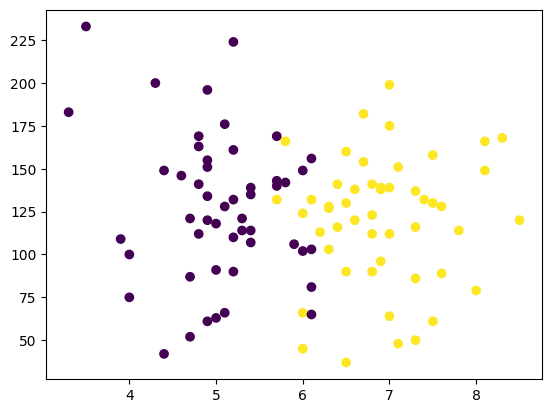

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [16]:
X.shape

(100, 2)

In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
y.shape

(100,)

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [20]:
X_train

,cgpa,iq
63,6.3,128.0
38,6.5,160.0
31,3.9,109.0
2,5.3,121.0
42,7.6,89.0
...,...,...
40,4.9,134.0
52,7.0,175.0
11,6.9,138.0
28,5.2,90.0


In [21]:
y_train

63    1
38    1
31    0
2     0
42    1
     ..
40    0
52    1
11    1
28    0
50    0
Name: placement, Length: 90, dtype: int64

In [22]:
X_test

,cgpa,iq
97,6.7,182.0
12,5.4,139.0
85,5.8,166.0
53,8.3,168.0
24,4.7,121.0
55,7.8,114.0
15,5.1,176.0
41,5.4,114.0
22,4.9,120.0
4,5.8,142.0


In [23]:
y_test

97    1
12    0
85    1
53    1
24    0
55    1
15    0
41    0
22    0
4     0
Name: placement, dtype: int64

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
X_train = scaler.fit_transform(X_train)

In [27]:
X_train

array([[ 0.27213397,  0.16618559],
       [ 0.44833582,  0.95859368],
       [-1.84228823, -0.30430672],
       [-0.60887528, -0.00715368],
       [ 1.41744599, -0.79956178],
       [ 0.09593212,  0.2652366 ],
       [-0.69697621,  2.54340987],
       [-0.96127898,  0.83477992],
       [ 0.88884044,  0.43857587],
       [-1.04937991,  1.03288194],
       [-0.25647158,  1.18145846],
       [ 0.00783119, -1.3691051 ],
       [-0.25647158,  0.53762688],
       [ 0.97694137, -1.81483465],
       [ 0.71263859, -0.23001846],
       [-0.69697621,  0.2652366 ],
       [ 1.41744599,  0.16618559],
       [ 0.53643674, -0.03191644],
       [ 1.85795062,  1.1071702 ],
       [ 2.21035432, -0.03191644],
       [-1.13748083, -1.71578364],
       [ 1.85795062,  0.6862034 ],
       [ 0.09593212, -0.9976638 ],
       [-0.96127898, -1.49291886],
       [ 1.15314322, -0.87385004],
       [ 1.32934507,  0.21571109],
       [ 0.80073952, -0.62622251],
       [ 0.88884044, -0.23001846],
       [ 1.15314322,

In [29]:
X_test = scaler.transform(X_test)

In [30]:
X_test

array([[ 0.62453767,  1.50337425],
       [-0.52077436,  0.43857587],
       [-0.16837066,  1.1071702 ],
       [ 2.03415247,  1.15669571],
       [-1.13748083, -0.00715368],
       [ 1.59364784, -0.18049296],
       [-0.78507713,  1.35479773],
       [-0.52077436, -0.18049296],
       [-0.96127898, -0.03191644],
       [-0.16837066,  0.51286413]])

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
clf = LogisticRegression()

In [33]:
# Model Training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
y_pred = clf.predict(X_test)

In [37]:
y_test

97    1
12    0
85    1
53    1
24    0
55    1
15    0
41    0
22    0
4     0
Name: placement, dtype: int64

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test,y_pred)

0.9

In [40]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

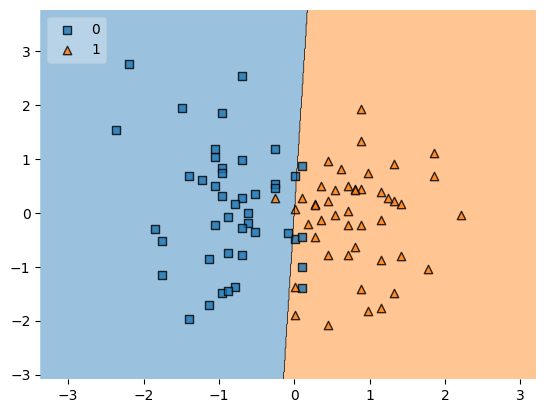

In [42]:
plot_decision_regions(X_train, y_train.values, clf=clf,legend=2)

In [43]:
import pickle

In [44]:
pickle.dump(clf,open('model.pkl', 'wb'))